 # Heat Wave & Cold Snap — ML Data Preparation



 **Purpose:**

 Transform the cleaned dataset into ML-ready feature matrices with

 engineered features, time-ordered splits, encoding, and scaling.



 **Prerequisite:** Run `data_preparation.ipynb` first to produce

 `data/processed/cleaned.csv`.



 **Objective (reminder):**

 We want a model that outputs *regional probabilities* of heat wave /

 cold snap on a given date, enabling queries like:

 - *"Which NERC region has the lowest heat-wave probability on date X?"*

 - *"If I travel to region Y on date X, what is the likelihood of a heat wave?"*



 **Notebook Structure:**

 ```

 0. Setup & Configuration

 1. Load Cleaned Data

 2. Feature Engineering

    2.1 Cyclical day-of-year (sin / cos)

    2.2 Region × Hazard 30-day trailing event rate

    2.3 Days since last same-type event in region

    2.4 Feature summary & correlation check

 3. Time-Ordered Train / Val / Test Split

 4. Target Encoding

 5. Categorical Encoding (One-Hot)

 6. Feature Scaling (fit on train only)

 7. Final Validation & Summary

 8. Save Outputs

 ```



 **Inputs:**  `data/processed/cleaned.csv`

 **Outputs:**

 ```

 data/processed/

 ├── ml_ready.csv              ← full dataset with engineered features

 ├── train.csv / val.csv / test.csv

 ├── X_train.csv / X_val.csv / X_test.csv   ← encoded & scaled

 ├── y_train.csv / y_val.csv / y_test.csv

 └── ml_artifacts/

     ├── scaler.joblib

     ├── label_encoder.joblib

     ├── feature_names.json

     ├── onehot_columns.json

     └── split_summary.txt

 ```

 ---

 ## 0. Setup & Configuration

In [132]:
# ── Standard library ─────────────────────────────────────────
import json
import warnings
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Notebook display settings ─────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 25)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 140)
%matplotlib inline
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.figsize":    (10, 4),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})
sns.set_palette("muted")


 ### 0.1 Reproducibility & paths

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── File paths ────────────────────────────────────────────────
ROOT_DIR     = Path("ESSD_AI_Competition_1/week2")
CLEANED_CSV  = ROOT_DIR / "data/processed/data_cleaned.csv"
PROC_DIR     = ROOT_DIR / "data/processed"
ARTIFACT_DIR = PROC_DIR / "ml_artifacts"
FIG_DIR      = ROOT_DIR / "figures/ml_preparation"

PROC_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


 ### 0.2 Schema & ML configuration



 These constants define the target, features, split ratios, and

 all engineering parameters. Change values here only.

In [134]:
# ── Column roles ──────────────────────────────────────────────
TARGET_COL      = "hazard_type"            # binary: heat_wave / cold_snap
EVENT_DATE_COL  = "centroid_date"          # temporal anchor per event
DATE_COLS       = ["start_date", "end_date", "centroid_date"]
TEMP_COL        = "extreme_temperature_C"  # cleaned column (from K→°C step)

# Original numeric features (post-cleaning column names)
NUM_FEATURES_ORIG = [
    "extreme_temperature_C",
    "duration_days",
    "spatial_coverage_pct",
    "def_percentile",       # ← NEW: definition strictness
    "def_min_duration",     # ← NEW: duration requirement
]

# Categorical features to one-hot encode
# definition_id is NOT one-hot encoded; instead we engineer
# meaningful features from it (see Section 2.0)
CAT_FEATURES = ["NERC_ID", "aggregation_method", "def_temp_metric"]

# Columns NOT used as features
DROP_FOR_ML = [
    "hazard_type",       # target — encoded separately
    "definition_id",     # replaced by engineered def_* features
    "start_date",
    "end_date",
    "centroid_date",
]

# ── Definition metadata lookup ────────────────────────────────
# Maps each definition to its physical characteristics [Ref: Event definitions.docx]
DEFINITION_META = {
    "Def1":  {"temp_metric": "daily_mean", "percentile": 90.0,  "min_duration": 2},
    "Def2":  {"temp_metric": "daily_mean", "percentile": 95.0,  "min_duration": 2},
    "Def3":  {"temp_metric": "daily_mean", "percentile": 98.0,  "min_duration": 2},
    "Def4":  {"temp_metric": "daily_mean", "percentile": 99.0,  "min_duration": 2},
    "Def5":  {"temp_metric": "daily_max",  "percentile": 95.0,  "min_duration": 2},
    "Def6":  {"temp_metric": "daily_max",  "percentile": 97.5,  "min_duration": 3},
    "Def7":  {"temp_metric": "daily_max",  "percentile": 90.0,  "min_duration": 3},
    "Def8":  {"temp_metric": "daily_max",  "percentile": 90.0,  "min_duration": 3},
    "Def9":  {"temp_metric": "daily_min",  "percentile": 95.0,  "min_duration": 2},
    "Def10": {"temp_metric": "daily_min",  "percentile": 97.5,  "min_duration": 3},
    "Def11": {"temp_metric": "daily_min",  "percentile": 90.0,  "min_duration": 3},
    "Def12": {"temp_metric": "daily_min",  "percentile": 90.0,  "min_duration": 3},
}

# ── Feature engineering parameters ────────────────────────────
ROLLING_WINDOW_DAYS = 30     # trailing window for historical rate
DAYS_SINCE_SENTINEL = 999    # fill for first event in a region/type group

# ── Train / val / test split (chronological) ─────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO = 0.15  (remainder)

print("✅ Configuration complete.")
print(f"   Input  : {CLEANED_CSV}")
print(f"   Target : '{TARGET_COL}'")
print(f"   Split  : {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / "
      f"{1 - TRAIN_RATIO - VAL_RATIO:.0%}")


✅ Configuration complete.
   Input  : C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\data_cleaned.csv
   Target : 'hazard_type'
   Split  : 70% / 15% / 15%


 ---

 ## 1. Load Cleaned Data

In [135]:
df = pd.read_csv(CLEANED_CSV, low_memory=False)

# Parse dates
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df[EVENT_DATE_COL].min().date()} → "
      f"{df[EVENT_DATE_COL].max().date()}")
print(f"\nColumns: {list(df.columns)}")


Loaded: 86,128 rows × 10 columns
Date range: 1980-01-01 → 2024-12-30

Columns: ['hazard_type', 'aggregation_method', 'definition_id', 'start_date', 'end_date', 'centroid_date', 'duration_days', 'NERC_ID', 'spatial_coverage_pct', 'extreme_temperature_C']


In [136]:
df.head()


,hazard_type,aggregation_method,definition_id,start_date,end_date,centroid_date,duration_days,NERC_ID,spatial_coverage_pct,extreme_temperature_C
0,cold_snap,mwa,Def1,1980-01-22,1980-01-24,1980-01-23,3,nerc1,75.0000,-2.9145
1,cold_snap,mwa,Def1,1982-01-03,1982-01-05,1982-01-04,3,nerc1,81.8182,-5.7100
2,cold_snap,mwa,Def1,1982-01-22,1982-01-23,1982-01-23,2,nerc1,72.7273,-5.4083
3,cold_snap,mwa,Def1,1982-01-30,1982-02-07,1982-02-06,9,nerc1,79.5455,-5.2321
4,cold_snap,mwa,Def1,1982-02-09,1982-02-10,1982-02-09,2,nerc1,56.8182,-2.6278


In [137]:
df.dtypes


hazard_type                         str
aggregation_method                  str
definition_id                       str
start_date               datetime64[us]
end_date                 datetime64[us]
centroid_date            datetime64[us]
duration_days                     int64
NERC_ID                             str
spatial_coverage_pct            float64
extreme_temperature_C           float64
dtype: object

In [138]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
start_date,86128,2002-11-27 07:43:30.551737,1980-01-01 00:00:00,1991-06-29 00:00:00,2003-02-15 00:00:00,2014-02-09 00:00:00,2024-12-29 00:00:00,NaN
end_date,86128,2002-12-02 16:24:24.945197,1980-01-02 00:00:00,1991-07-04 00:00:00,2003-02-19 00:00:00,2014-02-13 00:00:00,2024-12-31 00:00:00,NaN
centroid_date,86128,2002-11-29 21:45:30.596321,1980-01-01 00:00:00,1991-07-02 00:00:00,2003-02-16 00:00:00,2014-02-11 00:00:00,2024-12-30 00:00:00,NaN
duration_days,86128.0000,5.2456,2.0000,3.0000,4.0000,7.0000,13.0000,3.4831
spatial_coverage_pct,86128.0000,66.8309,0.0000,50.8772,67.2131,85.2459,100.0000,21.7244
extreme_temperature_C,86128.0000,12.2575,-43.6122,-7.1723,16.7248,32.8335,44.0497,21.6761


 ### 1.1 Confirm temperature is in °C

In [139]:
assert TEMP_COL in df.columns, (
    f"Expected '{TEMP_COL}' not found. "
    f"Available: {list(df.columns)}. "
    f"Did you run the cleaning notebook first?"
)
print(f"✅ Temperature column: '{TEMP_COL}'")
print(f"   Range: [{df[TEMP_COL].min():.2f} °C, {df[TEMP_COL].max():.2f} °C]")


✅ Temperature column: 'extreme_temperature_C'
   Range: [-43.61 °C, 44.05 °C]


### 1.2 Engineer definition-based features

| Feature | Type | Values | What it captures |
|---|---|---|---|
| `def_temp_metric` | categorical | daily_mean, daily_max, daily_min | Which temperature signal was used |
| `def_percentile` | numeric | 90 – 99 | How strict the threshold is |
| `def_min_duration` | numeric | 2 or 3 | Minimum consecutive days required |

This gives the model meaningful, interpretable features rather than arbitrary definition labels.

In [140]:
if "definition_id" in df.columns:
    print("Available definitions:")
    print(df["definition_id"].value_counts().sort_index().to_string())

    # Map definition metadata to new columns
    def_meta_df = pd.DataFrame(DEFINITION_META).T
    def_meta_df.index.name = "definition_id"
    def_meta_df = def_meta_df.reset_index()

    print(f"\n── Definition Metadata Lookup ──")
    display(def_meta_df)

    # Merge metadata into main dataframe
    n_before = len(df)
    df = df.merge(def_meta_df, on="definition_id", how="left")

    # Rename for clarity
    df = df.rename(columns={
        "temp_metric":  "def_temp_metric",
        "percentile":   "def_percentile",
        "min_duration":  "def_min_duration",
    })

    # Check for unmatched definitions
    n_unmatched = df["def_temp_metric"].isna().sum()
    if n_unmatched:
        print(f"⚠️  {n_unmatched} rows with unmapped definition_id — "
              f"filling with defaults")
        df["def_temp_metric"]  = df["def_temp_metric"].fillna("unknown")
        df["def_percentile"]   = df["def_percentile"].fillna(95.0)
        df["def_min_duration"] = df["def_min_duration"].fillna(2.0)

    print(f"\n✅ Definition features engineered:")
    print(f"   def_temp_metric  : {df['def_temp_metric'].unique()}")
    print(f"   def_percentile   : {sorted(df['def_percentile'].unique())}")
    print(f"   def_min_duration : {sorted(df['def_min_duration'].unique())}")
    print(f"   Rows unchanged   : {len(df)} (was {n_before})")
else:
    print("⚠️  'definition_id' column not found — skipping.")

Available definitions:
definition_id
Def1     13312
Def10     2403
Def11     7201
Def12     8627
Def2      7915
Def3      3612
Def4      1885
Def5      7979
Def6      2563
Def7      7092
Def8      9221
Def9     14318

── Definition Metadata Lookup ──


,definition_id,temp_metric,percentile,min_duration
0,Def1,daily_mean,90.0000,2
1,Def2,daily_mean,95.0000,2
2,Def3,daily_mean,98.0000,2
3,Def4,daily_mean,99.0000,2
4,Def5,daily_max,95.0000,2
5,Def6,daily_max,97.5000,3
6,Def7,daily_max,90.0000,3
7,Def8,daily_max,90.0000,3
8,Def9,daily_min,95.0000,2
9,Def10,daily_min,97.5000,3



✅ Definition features engineered:
   def_temp_metric  : ['daily_mean' 'daily_min' 'daily_max']
   def_percentile   : [90.0, 95.0, 97.5, 98.0, 99.0]
   def_min_duration : [2, 3]
   Rows unchanged   : 86128 (was 86128)


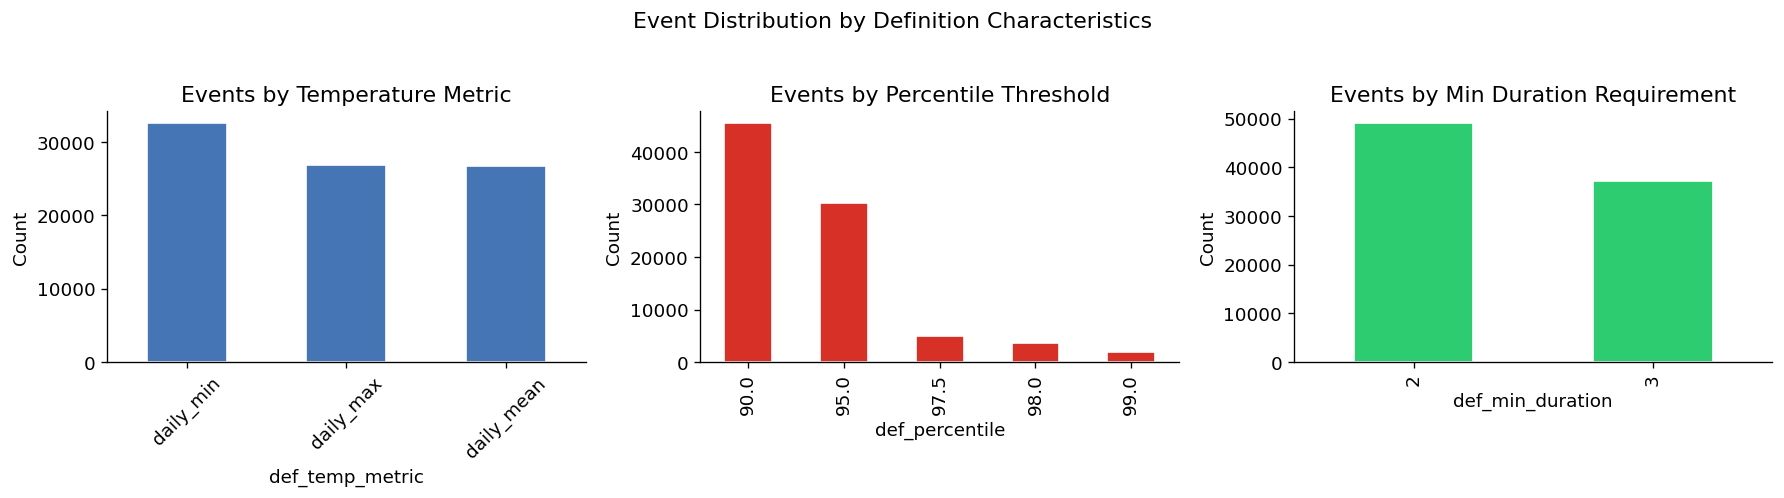

In [141]:
# Visualise: event counts by definition characteristics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["def_temp_metric"].value_counts().plot.bar(
    ax=axes[0], color="#4575b4", edgecolor="white")
axes[0].set_title("Events by Temperature Metric")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

df["def_percentile"].value_counts().sort_index().plot.bar(
    ax=axes[1], color="#d73027", edgecolor="white")
axes[1].set_title("Events by Percentile Threshold")
axes[1].set_ylabel("Count")

df["def_min_duration"].value_counts().sort_index().plot.bar(
    ax=axes[2], color="#2ecc71", edgecolor="white")
axes[2].set_title("Events by Min Duration Requirement")
axes[2].set_ylabel("Count")

plt.suptitle("Event Distribution by Definition Characteristics", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_01b_definition_features.png")
plt.show()

 ### 1.3 Confirm target distribution

             count     pct
hazard_type               
heat_wave    43546 50.6000
cold_snap    42582 49.4000


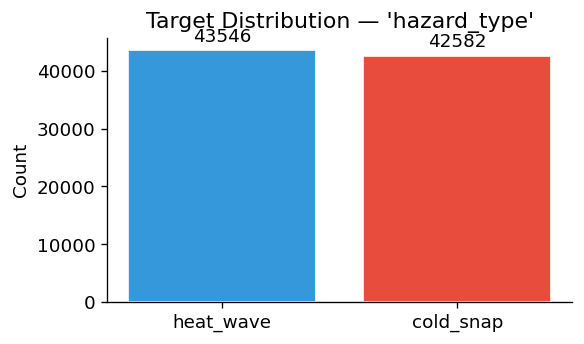

In [142]:
vc = df[TARGET_COL].value_counts()
print(vc.to_frame("count").assign(pct=(vc / vc.sum() * 100).round(1)))

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(vc.index, vc.values, color=["#3498db", "#e74c3c"],
              edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_title(f"Target Distribution — '{TARGET_COL}'")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_01_target_distribution.png")
plt.show()


 ---

 ## 2. Feature Engineering



 Three new features are added, all computed in a **leakage-safe** manner:

 each row's feature uses only information from **before** that row's date.



| # | Feature | How | Why |
|---|---|---|---|
| 1 | `doy_sin`, `doy_cos` | Cyclical encoding of day-of-year from `centroid_date` | Smooth seasonal signal; Dec 31 ≈ Jan 1 |
| 2 | `region_hazard_rate_30d` | Count of same-type events in same NERC region in trailing 30 days ÷ 30 | Regional climatological base rate |
| 3 | `days_since_last_event` | Days since previous same-type event in same region | Event clustering / persistence signal |

In [143]:
# Sort by date globally — all lag / rolling computations depend on this order
df = df.sort_values(EVENT_DATE_COL).reset_index(drop=True)
print(f"Dataset sorted by '{EVENT_DATE_COL}'.")


Dataset sorted by 'centroid_date'.


 ### 2.1 Feature 1 — Cyclical Day-of-Year



 Day-of-year (1–365) is encoded using sine and cosine so that the

 model sees a smooth cycle: day 365 is adjacent to day 1, not 364

 steps away.



 ```

 doy_sin = sin(2π × day_of_year / 365)

 doy_cos = cos(2π × day_of_year / 365)

 ```



 **Leakage risk:** None — computed from the event's own date only.

In [144]:
doy = df[EVENT_DATE_COL].dt.dayofyear

df["doy_sin"] = np.sin(2 * np.pi * doy / 365.0)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.0)

print("✅ Feature 1 created: doy_sin, doy_cos")
print(f"   doy_sin range: [{df['doy_sin'].min():.4f}, {df['doy_sin'].max():.4f}]")
print(f"   doy_cos range: [{df['doy_cos'].min():.4f}, {df['doy_cos'].max():.4f}]")


✅ Feature 1 created: doy_sin, doy_cos
   doy_sin range: [-1.0000, 1.0000]
   doy_cos range: [-1.0000, 1.0000]


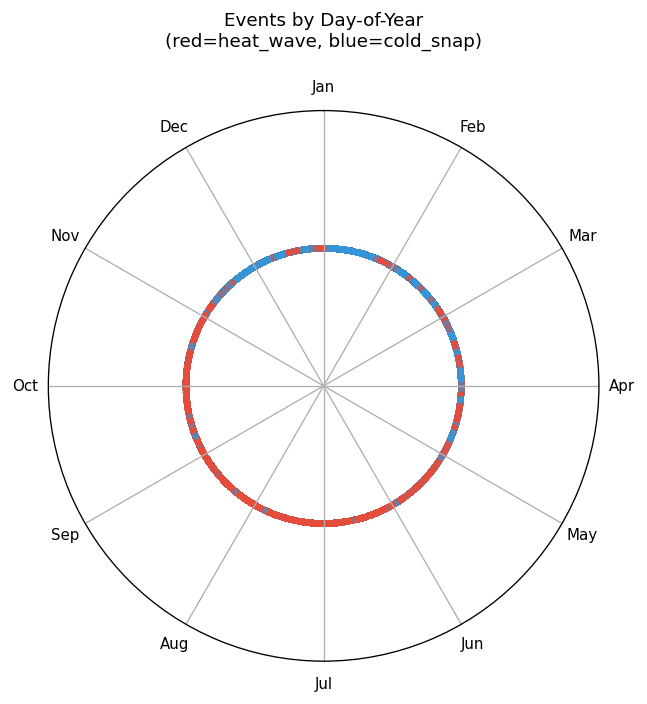

In [145]:
# Visualise: polar plot of events coloured by hazard type
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})

theta = 2 * np.pi * doy / 365.0
colors = df[TARGET_COL].map({"heat_wave": "#e74c3c", "cold_snap": "#3498db"})

ax.scatter(theta, np.ones(len(theta)), c=colors, s=8, alpha=0.4)
ax.set_theta_zero_location("N")       # Jan at top
ax.set_theta_direction(-1)             # clockwise
ax.set_yticks([])

# Month labels
month_angles = [2 * np.pi * m / 12 for m in range(12)]
month_names  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(month_angles)
ax.set_xticklabels(month_names, fontsize=9)
ax.set_title("Events by Day-of-Year\n(red=heat_wave, blue=cold_snap)",
             pad=20, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_02_doy_polar.png")
plt.show()


 ### 2.2 Feature 2 — Region × Hazard 30-Day Trailing Event Rate



 For each event row, count how many events of the **same hazard_type**

 occurred in the **same NERC_ID** during the **30 days before** (not

 including) the event's `centroid_date`, then divide by 30.



 ```

 rate = count_of_events_in_[date-30d, date-1d]  /  30

 ```



 **Leakage safety:**

 - Only events with `date < current_row_date` are counted.

 - The current row is never included in its own count.

 - No future information is used.

In [146]:
df["_event_dt"] = df[EVENT_DATE_COL].dt.normalize()

# Include definition_id so the same physical event detected by
# multiple definitions doesn't inflate the trailing count
GROUP_COLS = ["NERC_ID", "hazard_type", "definition_id"]


def compute_trailing_rate(group: pd.DataFrame) -> pd.Series:
    """
    For each row in the group (sorted by date), count events
    in the trailing 30-day window BEFORE the current date.
    Returns rate = count / ROLLING_WINDOW_DAYS.
    """
    dates  = group["_event_dt"].values  # already sorted globally
    counts = np.zeros(len(group), dtype=float)

    for i, dt in enumerate(dates):
        window_start = dt - np.timedelta64(ROLLING_WINDOW_DAYS, "D")
        # Strictly before current date and within window
        counts[i] = np.sum((dates < dt) & (dates >= window_start))

    return pd.Series(
        counts / ROLLING_WINDOW_DAYS,
        index=group.index,
    )


df["region_hazard_rate_30d"] = (
    df.groupby(GROUP_COLS, group_keys=False)
      .apply(compute_trailing_rate)
)

print("✅ Feature 2 created: region_hazard_rate_30d")
print(f"   Range: [{df['region_hazard_rate_30d'].min():.4f}, "
      f"{df['region_hazard_rate_30d'].max():.4f}]")
print(f"   Mean:  {df['region_hazard_rate_30d'].mean():.4f}")
print(f"   Zeros: {(df['region_hazard_rate_30d'] == 0).sum():,} "
      f"({(df['region_hazard_rate_30d'] == 0).mean():.1%})")


✅ Feature 2 created: region_hazard_rate_30d
   Range: [0.0000, 0.3333]
   Mean:  0.0489
   Zeros: 29,567 (34.3%)


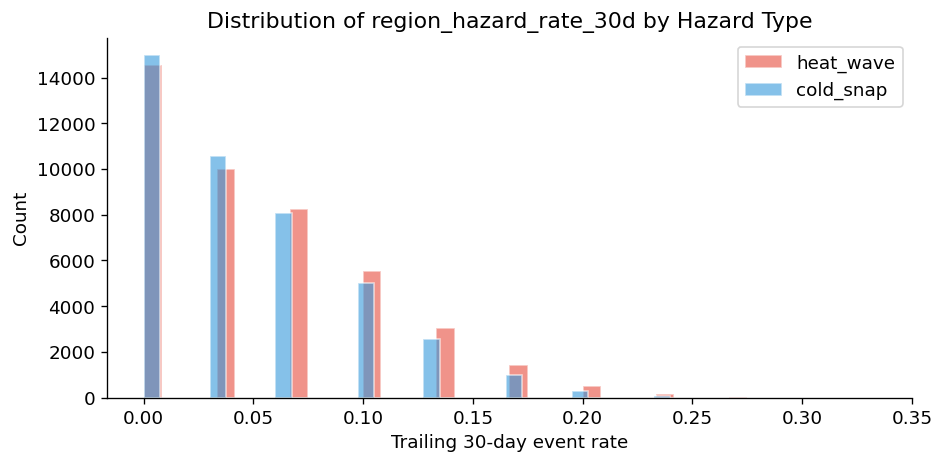

In [147]:
fig, ax = plt.subplots(figsize=(8, 4))
for htype, color in [("heat_wave", "#e74c3c"), ("cold_snap", "#3498db")]:
    subset = df[df[TARGET_COL] == htype]
    ax.hist(subset["region_hazard_rate_30d"], bins=40, alpha=0.6,
            label=htype, color=color, edgecolor="white")
ax.set_xlabel("Trailing 30-day event rate")
ax.set_ylabel("Count")
ax.set_title("Distribution of region_hazard_rate_30d by Hazard Type")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_03_trailing_rate_dist.png")
plt.show()


 ### 2.3 Feature 3 — Days Since Last Same-Type Event in Region



 For each row, compute the number of days since the **previous** event

 of the **same hazard_type** in the **same NERC_ID**.



 - Uses `shift(1)` within each `(NERC_ID, hazard_type)` group sorted

   by date — strictly the **preceding** row.

 - First event in each group has no predecessor → filled with sentinel

   value `999` (large gap = no recent history).



 **Leakage safety:** `shift(1)` guarantees only past data is used.

In [148]:
def compute_days_since_last(group: pd.DataFrame) -> pd.Series:
    """
    Within a (NERC_ID, hazard_type) group sorted by date,
    compute days elapsed since the previous event.
    """
    sorted_grp = group.sort_values("_event_dt")
    prev_date  = sorted_grp["_event_dt"].shift(1)
    days_since = (sorted_grp["_event_dt"] - prev_date).dt.days
    # First event in group → no predecessor → sentinel
    days_since = days_since.fillna(DAYS_SINCE_SENTINEL)
    return days_since


df["days_since_last_event"] = (
    df.groupby(GROUP_COLS, group_keys=False)
      .apply(compute_days_since_last)
)

# Drop helper column
df = df.drop(columns=["_event_dt"])

print("✅ Feature 3 created: days_since_last_event")
print(f"   Range: [{df['days_since_last_event'].min():.0f}, "
      f"{df['days_since_last_event'].max():.0f}]")
print(f"   Mean:  {df['days_since_last_event'].mean():.1f}")
print(f"   Sentinel ({DAYS_SINCE_SENTINEL}): "
      f"{(df['days_since_last_event'] == DAYS_SINCE_SENTINEL).sum():,} rows "
      f"(first event per region/type group)")


✅ Feature 3 created: days_since_last_event
   Range: [0, 3291]
   Mean:  76.2
   Sentinel (999): 384 rows (first event per region/type group)


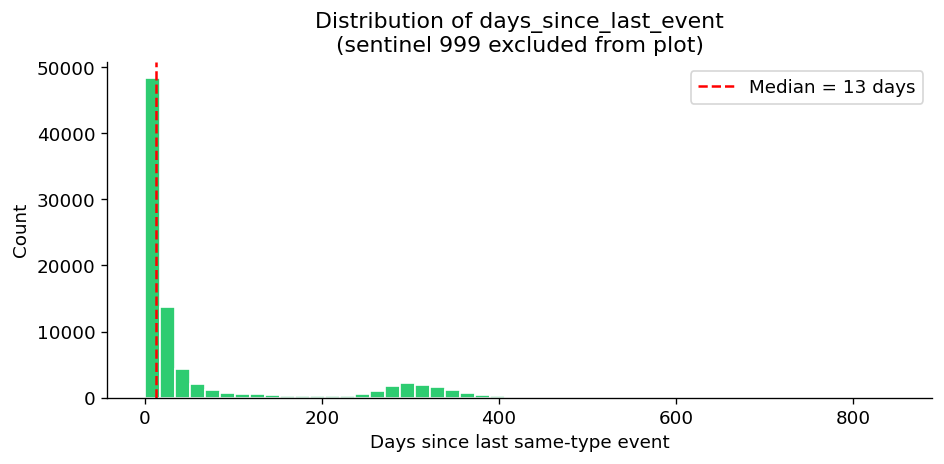

In [149]:
fig, ax = plt.subplots(figsize=(8, 4))
# Exclude sentinel for cleaner visualisation
non_sentinel = df.loc[
    df["days_since_last_event"] < DAYS_SINCE_SENTINEL,
    "days_since_last_event"
]
ax.hist(non_sentinel, bins=50, color="#2ecc71", edgecolor="white")
ax.axvline(non_sentinel.median(), color="red", linestyle="--",
           label=f"Median = {non_sentinel.median():.0f} days")
ax.set_xlabel("Days since last same-type event")
ax.set_ylabel("Count")
ax.set_title("Distribution of days_since_last_event\n"
             f"(sentinel {DAYS_SINCE_SENTINEL} excluded from plot)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_04_days_since_last.png")
plt.show()


### 2.3b Create Daily Panel with Event Occurrence Target

The original data only contains rows where events occurred.
To predict "will an event happen?", we need **non-event days** too.

For each (NERC_ID × definition_id × hazard_type) combination,
create a daily time series and mark days that fall within an event
as `1`, all other days as `0`.

This reframes the problem from:
   "Is this event a heat wave or cold snap?" (temperature answers trivially)
 to:
  "On this date in this region, does a heat wave / cold snap occur?"
  (region, season, and historical patterns all matter)

═══ Creating Heat Wave Panel ═══
  Hazard type: heat_wave
  Date range: 1980-01-12 → 2024-12-31 (16,426 days)
  Regions: 16
  Definitions: 12
  Total event-days: 220,501
  Positive samples (event days)     : 220,501
  Negative samples (non-event days)  : 661,503
  Ratio: 1:3

═══ Creating Cold Snap Panel ═══
  Hazard type: cold_snap
  Date range: 1980-01-01 → 2024-12-28 (16,434 days)
  Regions: 16
  Definitions: 12
  Total event-days: 196,868
  Positive samples (event days)     : 196,868
  Negative samples (non-event days)  : 590,604
  Ratio: 1:3

═══ Combined Panel ═══
  Total rows: 1,669,476
  Event occurred distribution:
event_occurred
0    1252107
1     417369


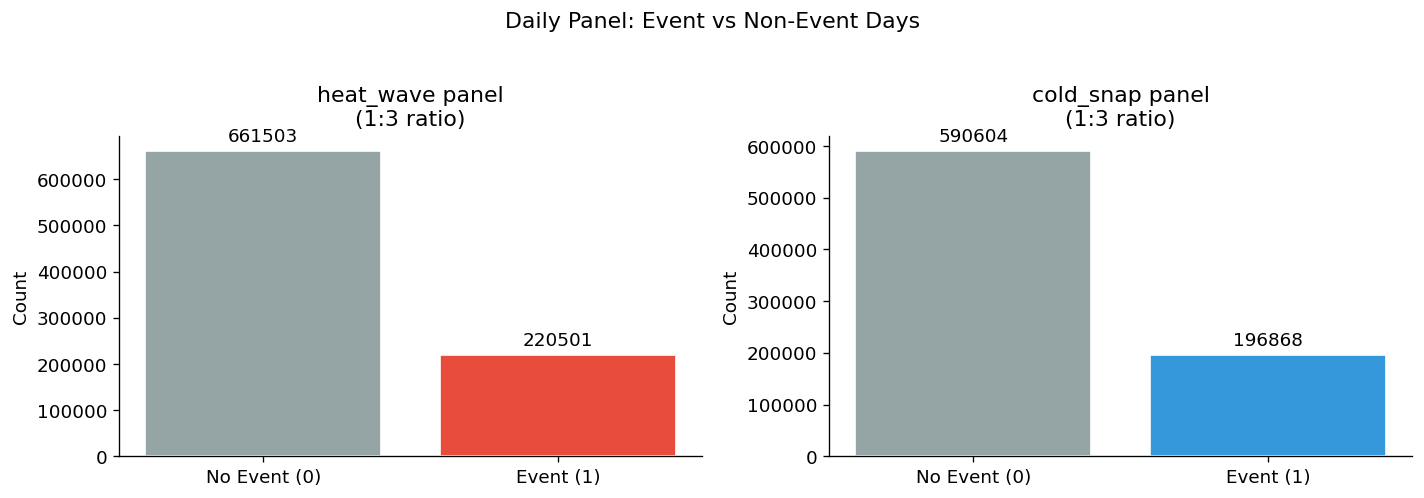

In [198]:

def create_daily_panel(
    df: pd.DataFrame,
    hazard_type: str = "heat_wave",
    sample_negative_ratio: int = 3,
) -> pd.DataFrame:
    """
    Create a daily panel dataset for one hazard type.

    Parameters
    ----------
    df : pd.DataFrame
        ML-ready dataset with events.
    hazard_type : str
        Which hazard type to model ("heat_wave" or "cold_snap").
    sample_negative_ratio : int
        Ratio of non-event to event days to keep (for balance).
        E.g., 3 means keep 3 non-event days per event day.

    Returns
    -------
    pd.DataFrame with one row per (region, date) and binary target.
    """
    # Filter to the chosen hazard type
    events = df[df["hazard_type"] == hazard_type].copy()

    # Get date range and all regions
    date_min = events["start_date"].min()
    date_max = events["end_date"].max()
    all_dates = pd.date_range(date_min, date_max, freq="D")
    all_regions = sorted(events["NERC_ID"].unique())
    all_definitions = sorted(events["definition_id"].unique())

    print(f"  Hazard type: {hazard_type}")
    print(f"  Date range: {date_min.date()} → {date_max.date()} "
          f"({len(all_dates):,} days)")
    print(f"  Regions: {len(all_regions)}")
    print(f"  Definitions: {len(all_definitions)}")

    # ── Mark event days ───────────────────────────────────
    # Expand each event to its individual days
    event_days = set()
    event_metadata = {}

    for _, row in events.iterrows():
        dates_in_event = pd.date_range(row["start_date"], row["end_date"])
        for d in dates_in_event:
            key = (row["NERC_ID"], row["definition_id"], d)
            event_days.add(key)
            event_metadata[key] = {
                "extreme_temperature_C": row["extreme_temperature_C"],
                "duration_days":         row["duration_days"],
                "spatial_coverage_pct":  row["spatial_coverage_pct"],
                "def_percentile":        row.get("def_percentile", 95.0),
                "def_min_duration":      row.get("def_min_duration", 2.0),
                "def_temp_metric":       row.get("def_temp_metric", "daily_mean"),
                "aggregation_method":    row.get("aggregation_method", "unknown"),
            }

    print(f"  Total event-days: {len(event_days):,}")

    # ── Build positive samples (event days) ───────────────
    positive_rows = []
    for (region, defn, date), meta in event_metadata.items():
        doy = date.dayofyear
        positive_rows.append({
            "date":                   date,
            "NERC_ID":                region,
            "definition_id":          defn,
            "event_occurred":         1,
            "extreme_temperature_C":  meta["extreme_temperature_C"],
            "duration_days":          meta["duration_days"],
            "spatial_coverage_pct":   meta["spatial_coverage_pct"],
            "def_percentile":         meta["def_percentile"],
            "def_min_duration":       meta["def_min_duration"],
            "def_temp_metric":        meta["def_temp_metric"],
            "aggregation_method":     meta["aggregation_method"],
            "doy_sin":                np.sin(2 * np.pi * doy / 365.0),
            "doy_cos":               np.cos(2 * np.pi * doy / 365.0),
        })

    # ── Build negative samples (non-event days) ──────────
    # Sample a balanced subset rather than ALL non-event days
    n_positive = len(positive_rows)
    n_negative_target = n_positive * sample_negative_ratio

    negative_rows = []
    np.random.seed(RANDOM_SEED)

    # Convert date range to pandas Timestamps for consistent API
    all_dates_ts = pd.DatetimeIndex(all_dates)

    attempts = 0
    max_attempts = n_negative_target * 10

    while len(negative_rows) < n_negative_target and attempts < max_attempts:
        rand_region = np.random.choice(all_regions)
        rand_defn   = np.random.choice(all_definitions)

        # ── Key fix: ensure we get a pandas Timestamp ─────
        rand_date   = pd.Timestamp(np.random.choice(all_dates_ts))

        attempts += 1

        key = (rand_region, rand_defn, rand_date)
        if key in event_days:
            continue

        doy = rand_date.dayofyear  # now works correctly

        # For non-event days, use regional seasonal median features
        region_seasonal = events[
            (events["NERC_ID"] == rand_region) &
            (events["definition_id"] == rand_defn)
        ]

        # Get definition metadata safely
        defn_rows = events[events["definition_id"] == rand_defn]

        negative_rows.append({
            "date":                   rand_date,
            "NERC_ID":                rand_region,
            "definition_id":          rand_defn,
            "event_occurred":         0,
            "extreme_temperature_C":  region_seasonal["extreme_temperature_C"].median()
                                      if len(region_seasonal) else 15.0,
            "duration_days":          0.0,
            "spatial_coverage_pct":   0.0,
            "def_percentile":         defn_rows["def_percentile"].iloc[0]
                                      if len(defn_rows) else 95.0,
            "def_min_duration":       defn_rows["def_min_duration"].iloc[0]
                                      if len(defn_rows) else 2.0,
            "def_temp_metric":        defn_rows["def_temp_metric"].iloc[0]
                                      if len(defn_rows) else "daily_mean",
            "aggregation_method":     region_seasonal["aggregation_method"].mode()[0]
                                      if len(region_seasonal) else "unknown",
            "doy_sin":                np.sin(2 * np.pi * doy / 365.0),
            "doy_cos":                np.cos(2 * np.pi * doy / 365.0),
        })

    print(f"  Positive samples (event days)     : {len(positive_rows):,}")
    print(f"  Negative samples (non-event days)  : {len(negative_rows):,}")
    print(f"  Ratio: 1:{sample_negative_ratio}")

    # ── Combine and sort ──────────────────────────────────
    panel = pd.DataFrame(positive_rows + negative_rows)
    panel = panel.sort_values("date").reset_index(drop=True)

    return panel


# ── Create panels for both hazard types ───────────────────
print("═══ Creating Heat Wave Panel ═══")
hw_panel = create_daily_panel(df, hazard_type="heat_wave", sample_negative_ratio=3)

print("\n═══ Creating Cold Snap Panel ═══")
cs_panel = create_daily_panel(df, hazard_type="cold_snap", sample_negative_ratio=3)

# ── Combine into one dataset ──────────────────────────────
hw_panel["hazard_query"] = "heat_wave"
cs_panel["hazard_query"] = "cold_snap"
panel_df = pd.concat([hw_panel, cs_panel], ignore_index=True)
panel_df = panel_df.sort_values("date").reset_index(drop=True)

print(f"\n═══ Combined Panel ═══")
print(f"  Total rows: {len(panel_df):,}")
print(f"  Event occurred distribution:")
print(panel_df["event_occurred"].value_counts().to_string())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, htype in zip(axes, ["heat_wave", "cold_snap"]):
    subset = panel_df[panel_df["hazard_query"] == htype]
    vc = subset["event_occurred"].value_counts()
    bars = ax.bar(["No Event (0)", "Event (1)"], vc.values,
                  color=["#95a5a6", "#e74c3c" if htype == "heat_wave" else "#3498db"],
                  edgecolor="white")
    ax.bar_label(bars, padding=3)
    ax.set_title(f"{htype} panel\n(1:{vc[0]//max(vc[1],1)} ratio)")
    ax.set_ylabel("Count")

plt.suptitle("Daily Panel: Event vs Non-Event Days", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_02b_panel_balance.png")
plt.show()

 ### 2.4 Feature Summary & Correlation Check

In [199]:
ENGINEERED_FEATURES = [
    "doy_sin", "doy_cos",
    "region_hazard_rate_30d",
    "days_since_last_event",
]

# Definition-derived features (engineered from definition_id metadata)
DEFINITION_FEATURES_NUM = ["def_percentile", "def_min_duration"]
DEFINITION_FEATURES_CAT = ["def_temp_metric"]

ALL_NUM_FEATURES = NUM_FEATURES_ORIG + ENGINEERED_FEATURES
# Note: NUM_FEATURES_ORIG already includes def_percentile & def_min_duration
# from the Section 0.2 config update

print("── Feature Groups ──────────────────────────────────")
print(f"\n  Original numeric features:")
for f in NUM_FEATURES_ORIG:
    tag = " (from definition metadata)" if f in DEFINITION_FEATURES_NUM else ""
    print(f"    • {f}{tag}")

print(f"\n  Engineered time-series features:")
for f in ENGINEERED_FEATURES:
    print(f"    • {f}")

print(f"\n  Categorical features (will be one-hot encoded):")
for f in CAT_FEATURES:
    tag = " (from definition metadata)" if f in DEFINITION_FEATURES_CAT else ""
    print(f"    • {f}{tag}")

print(f"\n  Total numeric: {len(ALL_NUM_FEATURES)}")
print(f"  Total categorical: {len(CAT_FEATURES)}")


── Feature Groups ──────────────────────────────────

  Original numeric features:
    • extreme_temperature_C
    • duration_days
    • spatial_coverage_pct
    • def_percentile (from definition metadata)
    • def_min_duration (from definition metadata)

  Engineered time-series features:
    • doy_sin
    • doy_cos
    • region_hazard_rate_30d
    • days_since_last_event

  Categorical features (will be one-hot encoded):
    • NERC_ID
    • aggregation_method
    • def_temp_metric (from definition metadata)

  Total numeric: 9
  Total categorical: 3


In [200]:
print("── Engineered Feature Summary ──────────────────────")
display(df[ENGINEERED_FEATURES].describe().T)


print("── Definition Feature Summary ─────────────────────")
display(df[DEFINITION_FEATURES_NUM].describe().T)
print(f"\ndef_temp_metric distribution:")
print(df["def_temp_metric"].value_counts().to_string())


print("── All Numeric Features ────────────────────────────")
display(df[ALL_NUM_FEATURES].describe().T)


── Engineered Feature Summary ──────────────────────


,count,mean,std,min,25%,50%,75%,max
doy_sin,86128.0000,-0.0514,0.5586,-1.0000,-0.5161,-0.0860,0.3857,1.0000
doy_cos,86128.0000,-0.0065,0.8278,-1.0000,-0.8900,-0.0817,0.8939,1.0000
region_hazard_rate_30d,86128.0000,0.0489,0.0494,0.0000,0.0000,0.0333,0.0667,0.3333
days_since_last_event,86128.0000,76.1529,160.7282,0.0000,5.0000,13.0000,42.0000,3291.0000


── Definition Feature Summary ─────────────────────


,count,unique,top,freq
def_percentile,86128.0000,5.0000,90.0000,45453.0000
def_min_duration,86128.0000,2.0000,2.0000,49021.0000



def_temp_metric distribution:
def_temp_metric
daily_min     32549
daily_max     26855
daily_mean    26724
── All Numeric Features ────────────────────────────


,count,mean,std,min,25%,50%,75%,max
extreme_temperature_C,86128.0000,12.2575,21.6761,-43.6122,-7.1723,16.7248,32.8335,44.0497
duration_days,86128.0000,5.2456,3.4831,2.0000,3.0000,4.0000,7.0000,13.0000
spatial_coverage_pct,86128.0000,66.8309,21.7244,0.0000,50.8772,67.2131,85.2459,100.0000
doy_sin,86128.0000,-0.0514,0.5586,-1.0000,-0.5161,-0.0860,0.3857,1.0000
doy_cos,86128.0000,-0.0065,0.8278,-1.0000,-0.8900,-0.0817,0.8939,1.0000
region_hazard_rate_30d,86128.0000,0.0489,0.0494,0.0000,0.0000,0.0333,0.0667,0.3333
days_since_last_event,86128.0000,76.1529,160.7282,0.0000,5.0000,13.0000,42.0000,3291.0000


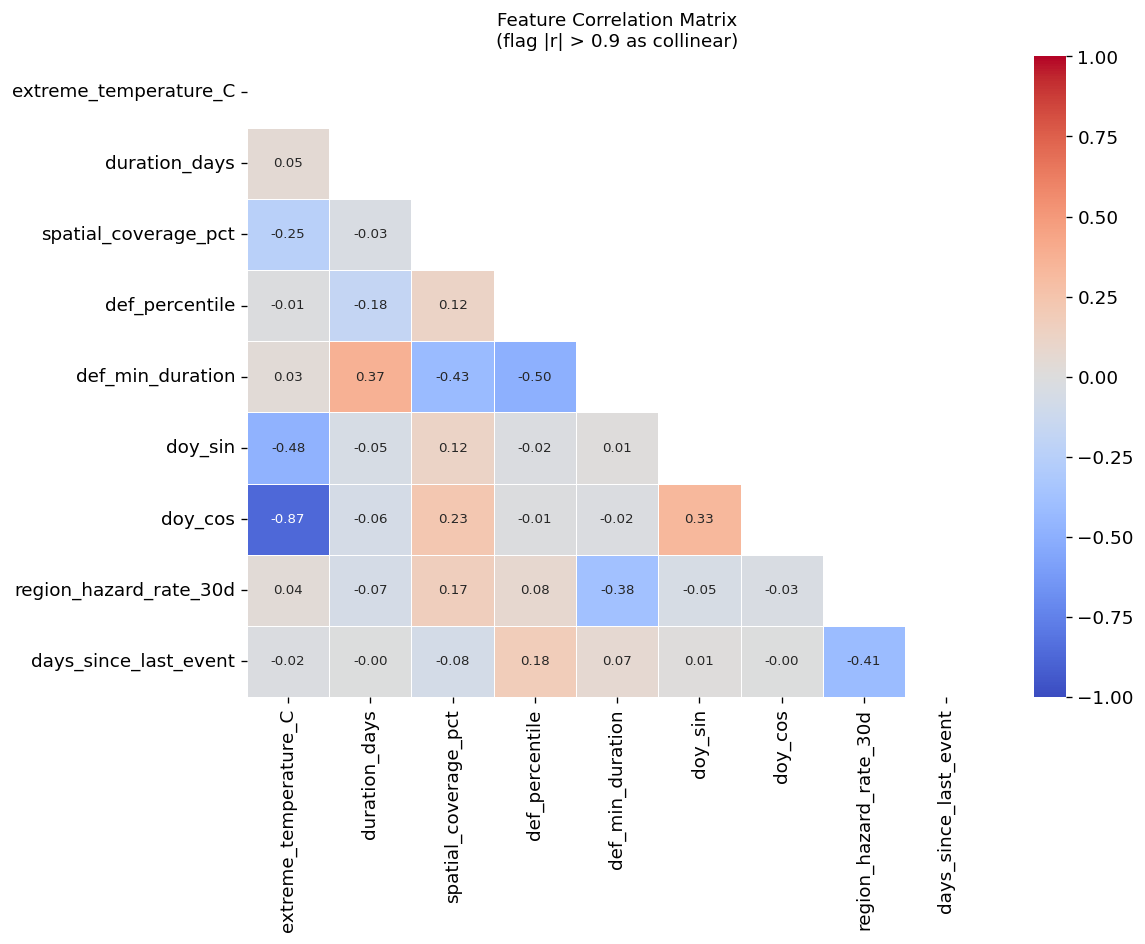

  ✅ No feature pairs with |r| > 0.9.


In [201]:
# Correlation matrix — check for collinearity
corr = df[ALL_NUM_FEATURES].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix\n"
             "(flag |r| > 0.9 as collinear)", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_05_correlation_matrix.png")
plt.show()

# Flag high correlations
HIGH_CORR = 0.9
high_pairs_found = False
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > HIGH_CORR:
            print(f"  🔴 High correlation: "
                  f"'{corr.columns[i]}' ↔ '{corr.columns[j]}' r={r:.4f}")
            high_pairs_found = True

if not high_pairs_found:
    print(f"  ✅ No feature pairs with |r| > {HIGH_CORR}.")


### 2.4.1 Definition features vs temperature — sanity check

We expect stricter definitions (higher percentile) to produce
events with more extreme temperatures. This validates that the
definition metadata was mapped correctly.

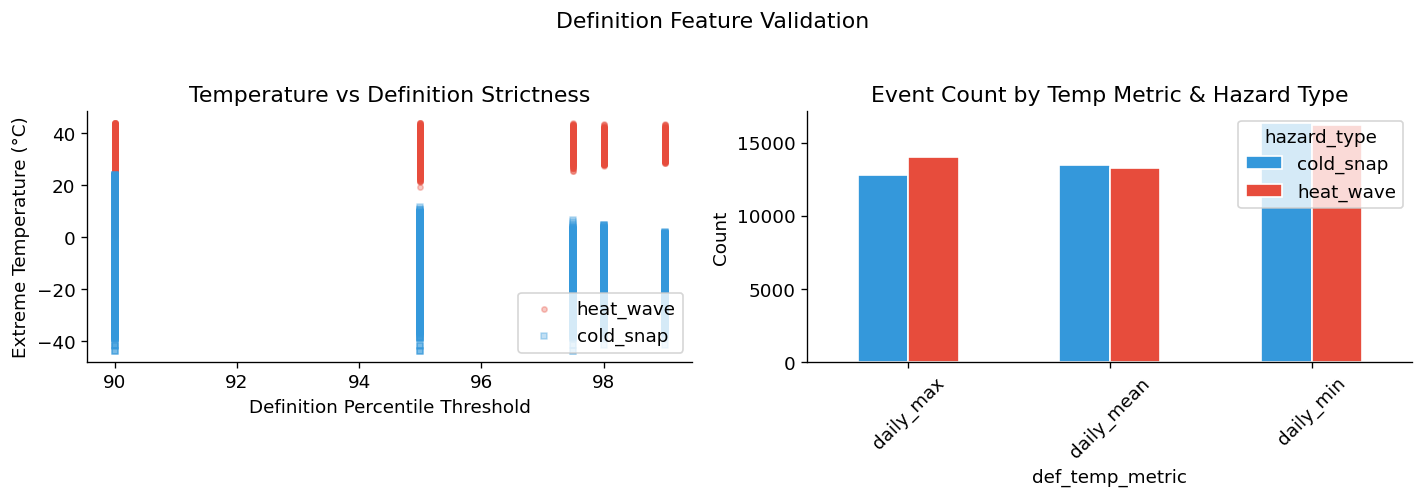

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Temperature vs percentile strictness
if "def_percentile" in df.columns and "extreme_temperature_C" in df.columns:
    for htype, color, marker in [("heat_wave", "#e74c3c", "o"),
                                   ("cold_snap", "#3498db", "s")]:
        subset = df[df["hazard_type"] == htype]
        axes[0].scatter(
            subset["def_percentile"],
            subset["extreme_temperature_C"],
            alpha=0.3, s=10, color=color, marker=marker, label=htype,
        )
    axes[0].set_xlabel("Definition Percentile Threshold")
    axes[0].set_ylabel("Extreme Temperature (°C)")
    axes[0].set_title("Temperature vs Definition Strictness")
    axes[0].legend()

# Event count by temp_metric and hazard_type
if "def_temp_metric" in df.columns:
    ct = df.groupby(["def_temp_metric", "hazard_type"]).size().unstack(fill_value=0)
    ct.plot.bar(ax=axes[1], color=["#3498db", "#e74c3c"], edgecolor="white")
    axes[1].set_title("Event Count by Temp Metric & Hazard Type")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(title="hazard_type")

plt.suptitle("Definition Feature Validation", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_05b_definition_validation.png")
plt.show()

 ### 2.5 Save ML-ready dataset (pre-split, pre-encoding)



 This file contains the cleaned data + engineered features in

 human-readable form — useful for EDA, sharing, and auditing.

In [203]:
ml_ready_path = PROC_DIR / "ml_ready.csv"
df.to_csv(ml_ready_path, index=False)
print(f"✅ ML-ready dataset saved → {ml_ready_path}")
print(f"   Shape: {df.shape}")


✅ ML-ready dataset saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_ready.csv
   Shape: (86128, 17)


 ---

 ## 3. Time-Ordered Train / Val / Test Split

Now splitting the **daily panel** dataset instead of the event-only
dataset. Each row is a (region, date, definition) with a binary target
`event_occurred` — the model learns when and where events happen.

 ### Why time-ordered (not random)?



 | Concern | Random split | Time split ✅ |
 |---|---|---|
 | **Data leakage** | Future events leak into training | Training uses only past data |
 | **Mirrors deployment** | Unrealistic | Model trained on past → predicts future |
 | **Lag features** | Past & future mixed → optimistic | Lag features are truly forward-looking |
 | **Evaluation** | Overly optimistic metrics | Realistic out-of-sample performance |



 ```

 ──────────────────────── time ──────────────────────────►
 │    TRAIN (70%)    │   VAL (15%)   │   TEST (15%)   │
 │  oldest events    │  mid events   │  newest events  │

 ```

In [204]:

# ── Use panel_df as the ML dataset ────────────────────────
TARGET_COL = "event_occurred"
EVENT_DATE_COL = "date"

panel_df = panel_df.sort_values(EVENT_DATE_COL).reset_index(drop=True)

n     = len(panel_df)
cut1  = int(n * TRAIN_RATIO)
cut2  = int(n * (TRAIN_RATIO + VAL_RATIO))

train = panel_df.iloc[:cut1].copy()
val   = panel_df.iloc[cut1:cut2].copy()
test  = panel_df.iloc[cut2:].copy()

print(f"Total rows: {n:,}")
print(f"  Train : {len(train):>8,} rows  "
      f"({train[EVENT_DATE_COL].min().date()} → "
      f"{train[EVENT_DATE_COL].max().date()})")
print(f"  Val   : {len(val):>8,} rows  "
      f"({val[EVENT_DATE_COL].min().date()} → "
      f"{val[EVENT_DATE_COL].max().date()})")
print(f"  Test  : {len(test):>8,} rows  "
      f"({test[EVENT_DATE_COL].min().date()} → "
      f"{test[EVENT_DATE_COL].max().date()})")
print(f"\nTarget distribution:")
for name, split in [("Train", train), ("Val", val), ("Test", test)]:
    vc = split[TARGET_COL].value_counts()
    print(f"  {name}: {vc.to_dict()}  "
          f"(event rate: {vc.get(1, 0)/len(split):.2%})")


Total rows: 1,669,476
  Train : 1,168,633 rows  (1980-01-01 → 2011-08-08)
  Val   :  250,421 rows  (2011-08-08 → 2018-05-27)
  Test  :  250,422 rows  (2018-05-27 → 2024-12-31)

Target distribution:
  Train: {0: 881191, 1: 287442}  (event rate: 24.60%)
  Val: {0: 189029, 1: 61392}  (event rate: 24.52%)
  Test: {0: 181887, 1: 68535}  (event rate: 27.37%)


 ### 3.1 Verify no temporal overlap between splits

In [205]:
assert train[EVENT_DATE_COL].max() <= val[EVENT_DATE_COL].min(), \
    "⚠️ Train/val overlap detected!"
assert val[EVENT_DATE_COL].max() <= test[EVENT_DATE_COL].min(), \
    "⚠️ Val/test overlap detected!"
print("✅ No temporal overlap between splits.")


✅ No temporal overlap between splits.


 ### 3.2 Class distribution per split



 Time-ordered splits can introduce class imbalance if event types

 are seasonal. We check and visualise this.

In [206]:
split_dist = pd.DataFrame({
    "Train": train[TARGET_COL].value_counts(),
    "Val":   val[TARGET_COL].value_counts(),
    "Test":  test[TARGET_COL].value_counts(),
}).fillna(0).astype(int)

split_pct = split_dist.div(split_dist.sum()) * 100

print("── Absolute counts ──")
print(split_dist.to_string())
print("\n── Percentage ──")
print(split_pct.round(1).to_string())


── Absolute counts ──
                 Train     Val    Test
event_occurred                        
0               881191  189029  181887
1               287442   61392   68535

── Percentage ──
                 Train     Val    Test
event_occurred                        
0              75.4000 75.5000 72.6000
1              24.6000 24.5000 27.4000


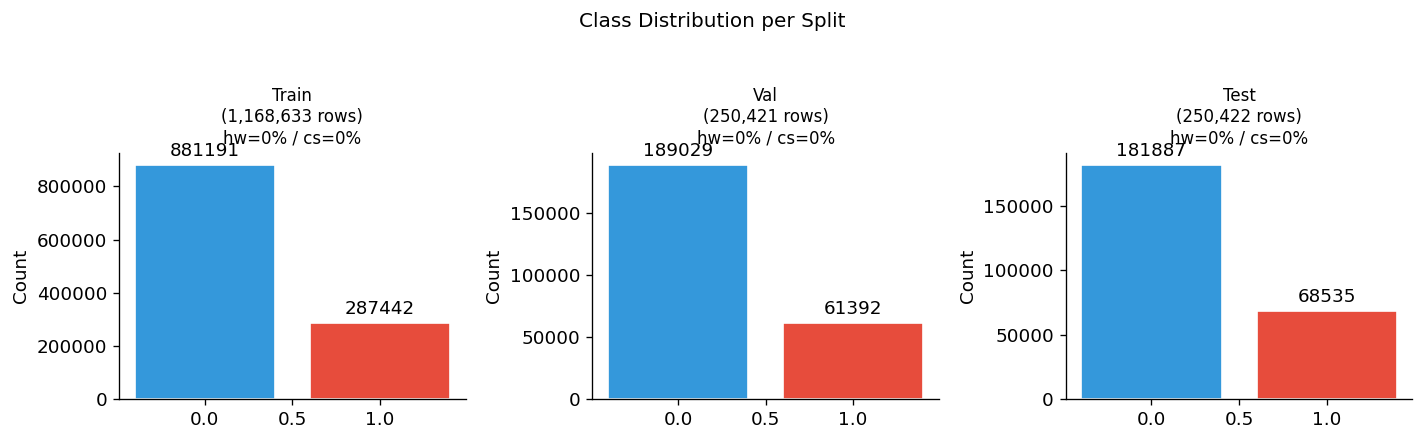

In [207]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, split_df) in zip(axes, [("Train", train),
                                         ("Val", val),
                                         ("Test", test)]):
    vc = split_df[TARGET_COL].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=["#3498db", "#e74c3c"], edgecolor="white")
    ax.bar_label(bars, padding=3)
    pct = vc / vc.sum() * 100
    ax.set_title(f"{name}\n({len(split_df):,} rows)\n"
                 f"hw={pct.get('heat_wave', 0):.0f}% / "
                 f"cs={pct.get('cold_snap', 0):.0f}%",
                 fontsize=10)
    ax.set_ylabel("Count")

plt.suptitle("Class Distribution per Split", y=1.04, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_06_split_class_dist.png")
plt.show()


 ### 3.3 Events per year per split (temporal coverage)

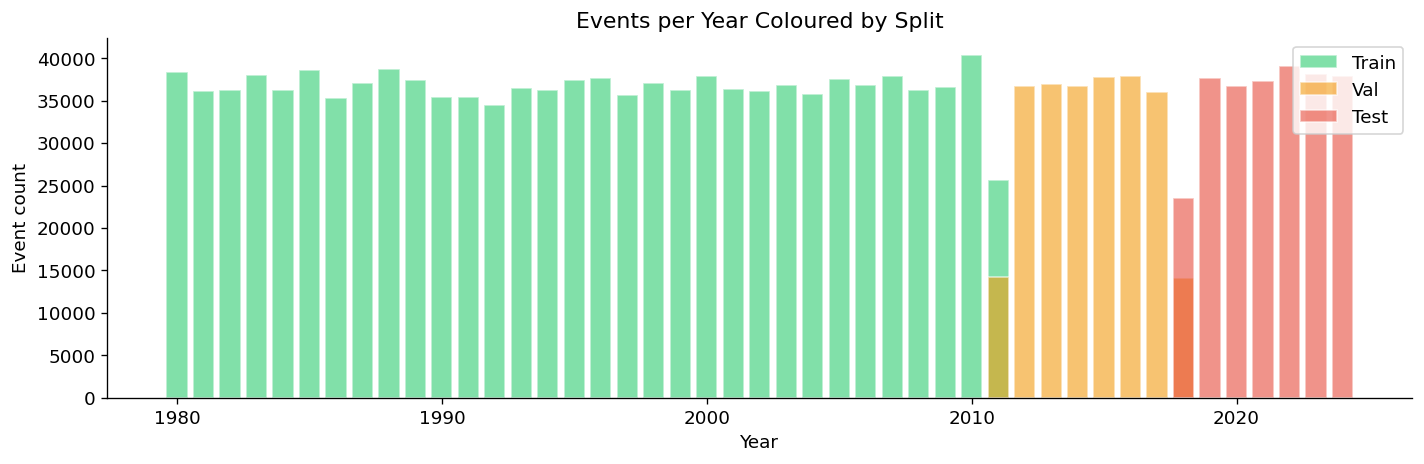

In [208]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, split_df, color in [("Train", train, "#2ecc71"),
                                ("Val",   val,   "#f39c12"),
                                ("Test",  test,  "#e74c3c")]:
    yearly = split_df.groupby(split_df[EVENT_DATE_COL].dt.year).size()
    ax.bar(yearly.index, yearly.values, alpha=0.6, label=name,
           color=color, edgecolor="white")

ax.set_xlabel("Year")
ax.set_ylabel("Event count")
ax.set_title("Events per Year Coloured by Split")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_07_events_per_year_split.png")
plt.show()


 ### 3.4 Save human-readable split CSVs

In [209]:
train.to_csv(PROC_DIR / "train.csv", index=False)
val.to_csv(PROC_DIR / "val.csv", index=False)
test.to_csv(PROC_DIR / "test.csv", index=False)
print("✅ Split CSVs saved: train.csv, val.csv, test.csv")


✅ Split CSVs saved: train.csv, val.csv, test.csv


 ---

 ## 4. Target Encoding



 `hazard_type` → integer via `LabelEncoder`:

 - `cold_snap` → 0

 - `heat_wave` → 1



 The encoder is **fit on the training set only** (though both classes are guaranteed present; this is best practice for consistency).

In [210]:

y_train = train[TARGET_COL].values
y_val   = val[TARGET_COL].values
y_test  = test[TARGET_COL].values

print(f"y_train: {np.bincount(y_train)} (shape {y_train.shape})")
print(f"y_val  : {np.bincount(y_val)}   (shape {y_val.shape})")
print(f"y_test : {np.bincount(y_test)}  (shape {y_test.shape})")

# Create a simple label encoder for compatibility with training notebook
le = LabelEncoder()
le.classes_ = np.array(["no_event", "event"])
le.fit(["no_event", "event"])

y_train: [881191 287442] (shape (1168633,))
y_val  : [189029  61392]   (shape (250421,))
y_test : [181887  68535]  (shape (250422,))


LabelEncoder()

 ---

 ## 5. Categorical Encoding (One-Hot)



 `NERC_ID` and `aggregation_method` are one-hot encoded.
 
 One-hot encoding creates a separate yes/no column for each category. Each column is either 1 (yes, this row belongs to this category) or 0 (no).


 **Leakage-safe approach:**

 1. Fit (discover categories) on **training set**.

 2. Transform val and test using the same column set.

 3. Categories unseen in training → all-zero vector in val/test

    (handled by `df.reindex(columns=..., fill_value=0)`).

 ### 5.1 Define feature columns for encoding

In [220]:
# ── Feature columns for the panel model ───────────────────
# After the daily panel restructuring, temperature/duration/coverage
# are excluded because they are not known at query time.
# The model predicts event occurrence from region, season, definition,
# and hazard query type.
NUM_FEATURES_PANEL = [
    "def_percentile",
    "def_min_duration",
    "doy_sin",
    "doy_cos",
]

CAT_FEATURES_PANEL = [
    "NERC_ID",
    "aggregation_method",
    "def_temp_metric",
    "hazard_query",          # ← this was missing from one-hot encoding
]

FEATURE_COLS = NUM_FEATURES_PANEL + CAT_FEATURES_PANEL
FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]

# Columns to drop (NOT used as features)
# extreme_temperature_C → excluded because we don't know it at query time
# duration_days         → excluded (0 for non-events, known only after event)
# spatial_coverage_pct  → excluded (same reason)
# date                  → used for split, not as feature
# definition_id         → replaced by def_* features
# event_occurred        → target

print(f"Feature columns ({len(FEATURE_COLS)}):")
for i, c in enumerate(FEATURE_COLS, 1):
    ftype = "CAT" if c in CAT_FEATURES_PANEL else "NUM"
    print(f"  {i:2d}. [{ftype}] {c}")

print(f"\n⚠️  Excluded from features (not known at query time):")
print(f"    extreme_temperature_C — the event hasn't happened yet")
print(f"    duration_days         — zero for non-events")
print(f"    spatial_coverage_pct  — zero for non-events")
print(f"    region_hazard_rate_30d — requires event history")
print(f"    days_since_last_event  — requires event history")

Feature columns (8):
   1. [NUM] def_percentile
   2. [NUM] def_min_duration
   3. [NUM] doy_sin
   4. [NUM] doy_cos
   5. [CAT] NERC_ID
   6. [CAT] aggregation_method
   7. [CAT] def_temp_metric
   8. [CAT] hazard_query

⚠️  Excluded from features (not known at query time):
    extreme_temperature_C — the event hasn't happened yet
    duration_days         — zero for non-events
    spatial_coverage_pct  — zero for non-events
    region_hazard_rate_30d — requires event history
    days_since_last_event  — requires event history


In [221]:
# Subset to feature columns only
X_train_raw = train[FEATURE_COLS].copy()
X_val_raw   = val[FEATURE_COLS].copy()
X_test_raw  = test[FEATURE_COLS].copy()

print(f"\nRaw feature shapes: "
      f"train={X_train_raw.shape}, "
      f"val={X_val_raw.shape}, "
      f"test={X_test_raw.shape}")



Raw feature shapes: train=(1168633, 8), val=(250421, 8), test=(250422, 8)


 ### 5.2 One-hot encode categoricals

In [222]:
# Subset to feature columns only
X_train_raw = train[FEATURE_COLS].copy()
X_val_raw   = val[FEATURE_COLS].copy()
X_test_raw  = test[FEATURE_COLS].copy()

print(f"\nRaw feature shapes: "
      f"train={X_train_raw.shape}, "
      f"val={X_val_raw.shape}, "
      f"test={X_test_raw.shape}")

# %%
# Identify which categorical columns are present
# ── KEY FIX: use CAT_FEATURES_PANEL instead of old CAT_FEATURES ──
cat_present = [c for c in CAT_FEATURES_PANEL if c in X_train_raw.columns]
print(f"Categorical columns to one-hot encode: {cat_present}")

# One-hot encode training set (this defines the column universe)
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_present)

# One-hot encode val and test
X_val_enc   = pd.get_dummies(X_val_raw, columns=cat_present)
X_test_enc  = pd.get_dummies(X_test_raw, columns=cat_present)

# Align val/test columns to train (handle unseen categories)
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Store final feature names and one-hot column names
feature_names = list(X_train_enc.columns)
onehot_cols   = [c for c in feature_names
                 if any(c.startswith(f"{cat}_") for cat in cat_present)]
num_feature_cols = [c for c in feature_names if c not in onehot_cols]

print(f"\n✅ After one-hot encoding:")
print(f"   Total features : {len(feature_names)}")
print(f"   Numeric        : {len(num_feature_cols)}")
print(f"   One-hot        : {len(onehot_cols)}")
print(f"\n   Encoded shapes: "
      f"train={X_train_enc.shape}, "
      f"val={X_val_enc.shape}, "
      f"test={X_test_enc.shape}")

# Verify no string columns remain in numeric features
print(f"\n── Numeric features (will be scaled) ──")
for col in num_feature_cols:
    print(f"  • {col}  dtype={X_train_enc[col].dtype}")
    assert X_train_enc[col].dtype in ["float64", "float32", "int64", "int32", "uint8"], \
        f"❌ '{col}' has non-numeric dtype: {X_train_enc[col].dtype}"
print("\n✅ All numeric features confirmed as numeric dtype.")


Raw feature shapes: train=(1168633, 8), val=(250421, 8), test=(250422, 8)
Categorical columns to one-hot encode: ['NERC_ID', 'aggregation_method', 'def_temp_metric', 'hazard_query']

✅ After one-hot encoding:
   Total features : 28
   Numeric        : 4
   One-hot        : 24

   Encoded shapes: train=(1168633, 28), val=(250421, 28), test=(250422, 28)

── Numeric features (will be scaled) ──
  • def_percentile  dtype=float64
  • def_min_duration  dtype=int64
  • doy_sin  dtype=float64
  • doy_cos  dtype=float64

✅ All numeric features confirmed as numeric dtype.


 ### 5.3 Inspect one-hot columns

In [223]:
print(f"── One-hot columns ({len(onehot_cols)}) ──")
for cat in cat_present:
    cols = [c for c in onehot_cols if c.startswith(f"{cat}_")]
    print(f"\n  '{cat}' → {len(cols)} dummy columns:")
    for c in sorted(cols):
        print(f"    {c}  (train sum: {X_train_enc[c].sum():.0f})")


── One-hot columns (24) ──

  'NERC_ID' → 16 dummy columns:
    NERC_ID_nerc1  (train sum: 75379)
    NERC_ID_nerc10  (train sum: 73079)
    NERC_ID_nerc11  (train sum: 71791)
    NERC_ID_nerc12  (train sum: 71807)
    NERC_ID_nerc15  (train sum: 72356)
    NERC_ID_nerc17  (train sum: 72730)
    NERC_ID_nerc18  (train sum: 73825)
    NERC_ID_nerc2  (train sum: 74575)
    NERC_ID_nerc20  (train sum: 72356)
    NERC_ID_nerc3  (train sum: 72366)
    NERC_ID_nerc4  (train sum: 72621)
    NERC_ID_nerc5  (train sum: 71963)
    NERC_ID_nerc6  (train sum: 74796)
    NERC_ID_nerc7  (train sum: 72392)
    NERC_ID_nerc8  (train sum: 73248)
    NERC_ID_nerc9  (train sum: 73349)

  'aggregation_method' → 3 dummy columns:
    aggregation_method_mwa  (train sum: 279178)
    aggregation_method_mwp  (train sum: 564521)
    aggregation_method_sm  (train sum: 324934)

  'def_temp_metric' → 3 dummy columns:
    def_temp_metric_daily_max  (train sum: 399077)
    def_temp_metric_daily_mean  (train sum: 3642

 ### 5.4 Check for unseen categories in val/test

In [224]:
train_cats = {
    cat: set(train[cat].unique()) for cat in cat_present
}
for split_name, split_df in [("Val", val), ("Test", test)]:
    for cat in cat_present:
        unseen = set(split_df[cat].unique()) - train_cats[cat]
        if unseen:
            print(f"  ⚠️  {split_name} has unseen '{cat}' values: {unseen} "
                  f"→ encoded as all-zero vector")
        else:
            print(f"  ✅ {split_name} '{cat}': all categories seen in train.")


  ✅ Val 'NERC_ID': all categories seen in train.
  ✅ Val 'aggregation_method': all categories seen in train.
  ✅ Val 'def_temp_metric': all categories seen in train.
  ✅ Val 'hazard_query': all categories seen in train.
  ✅ Test 'NERC_ID': all categories seen in train.
  ✅ Test 'aggregation_method': all categories seen in train.
  ✅ Test 'def_temp_metric': all categories seen in train.
  ✅ Test 'hazard_query': all categories seen in train.


 ---

 ## 6. Feature Scaling



 **StandardScaler** is applied to numeric features only (not one-hot

 encoded columns, which are already 0/1).



 **Fit on training data only** → transform val and test with the

 same mean and standard deviation. This prevents information from

 val/test leaking into the scaling parameters.

In [225]:
scaler = StandardScaler()

# Fit on train, transform all
X_train_enc[num_feature_cols] = scaler.fit_transform(
    X_train_enc[num_feature_cols]
)
X_val_enc[num_feature_cols] = scaler.transform(
    X_val_enc[num_feature_cols]
)
X_test_enc[num_feature_cols] = scaler.transform(
    X_test_enc[num_feature_cols]
)

print(f"✅ StandardScaler fit on {len(num_feature_cols)} numeric features "
      f"(train only)")
print(f"\n── Scaler parameters ──")
scale_params = pd.DataFrame({
    "feature": num_feature_cols,
    "mean":    scaler.mean_,
    "std":     scaler.scale_,
}).set_index("feature")
print(scale_params.to_string(float_format="{:.4f}".format))


✅ StandardScaler fit on 4 numeric features (train only)

── Scaler parameters ──
                    mean    std
feature                        
def_percentile   93.5635 3.4841
def_min_duration  2.5187 0.4996
doy_sin           0.0011 0.6753
doy_cos           0.0016 0.7376


In [226]:
# ── Verify definition features are included ──────────────────
print("── Definition feature verification ──\n")

# Check they exist in the encoded feature matrix
def_related = [c for c in X_train_enc.columns
               if c.startswith("def_")]

print(f"Definition-related columns in feature matrix: {len(def_related)}")
for col in sorted(def_related):
    col_type = "one-hot" if col in onehot_cols else "numeric (scaled)"
    print(f"  • {col}  [{col_type}]")

# Expected:
#   • def_min_duration              [numeric (scaled)]
#   • def_percentile                [numeric (scaled)]
#   • def_temp_metric_daily_max     [one-hot]
#   • def_temp_metric_daily_mean    [one-hot]
#   • def_temp_metric_daily_min     [one-hot]

expected_num = {"def_percentile", "def_min_duration"}
expected_cat_prefix = "def_temp_metric_"

missing_num = expected_num - set(def_related)
has_cat = any(c.startswith(expected_cat_prefix) for c in def_related)

if missing_num:
    print(f"\n⚠️  Missing numeric definition features: {missing_num}")
elif not has_cat:
    print(f"\n⚠️  No one-hot columns for def_temp_metric found!")
else:
    print(f"\n✅ All definition features present and correctly encoded.")

── Definition feature verification ──

Definition-related columns in feature matrix: 5
  • def_min_duration  [numeric (scaled)]
  • def_percentile  [numeric (scaled)]
  • def_temp_metric_daily_max  [one-hot]
  • def_temp_metric_daily_mean  [one-hot]
  • def_temp_metric_daily_min  [one-hot]

✅ All definition features present and correctly encoded.


 ### 6.1 Verify scaled distributions

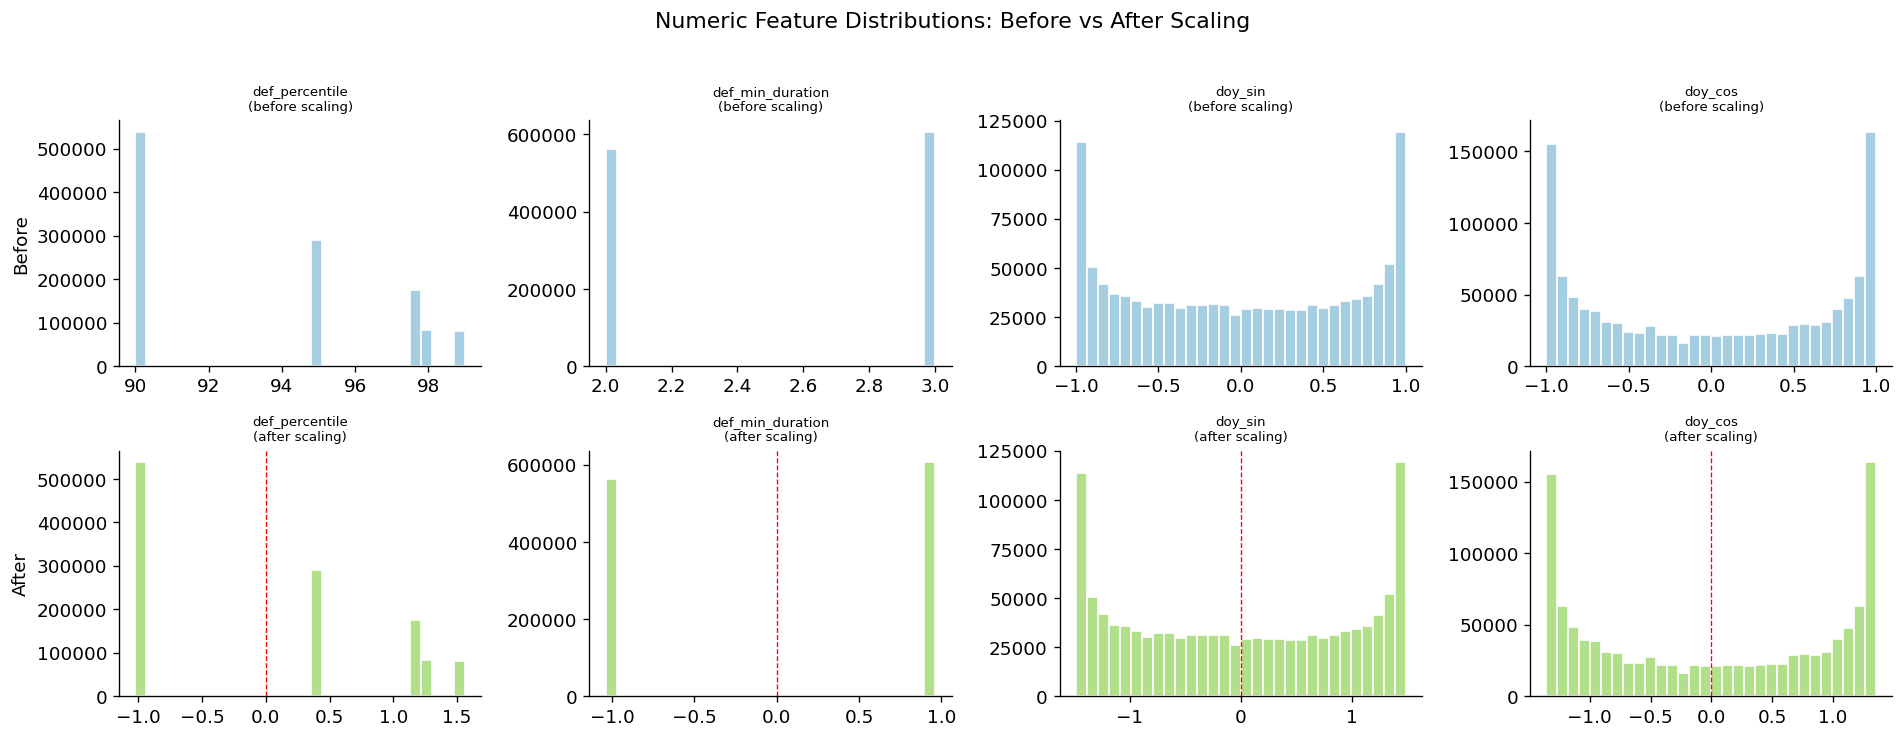

In [227]:
fig, axes = plt.subplots(2, len(num_feature_cols),
                         figsize=(4 * len(num_feature_cols), 6))

if len(num_feature_cols) == 1:
    axes = axes.reshape(-1, 1)

for j, col in enumerate(num_feature_cols):
    # Before scaling (from train raw)
    axes[0, j].hist(X_train_raw[col].dropna() if col in X_train_raw.columns
                    else [], bins=30, color="#a6cee3", edgecolor="white")
    axes[0, j].set_title(f"{col}\n(before scaling)", fontsize=8)

    # After scaling
    axes[1, j].hist(X_train_enc[col].dropna(), bins=30,
                    color="#b2df8a", edgecolor="white")
    axes[1, j].set_title(f"{col}\n(after scaling)", fontsize=8)
    axes[1, j].axvline(0, color="red", linestyle="--", linewidth=0.8)

axes[0, 0].set_ylabel("Before")
axes[1, 0].set_ylabel("After")
plt.suptitle("Numeric Feature Distributions: Before vs After Scaling", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_08_scaling_before_after.png")
plt.show()


 ---

 ## 7. Final Validation & Summary

 ### 7.1 Confirm no missing values in feature matrices

In [228]:
for name, X in [("X_train", X_train_enc),
                ("X_val",   X_val_enc),
                ("X_test",  X_test_enc)]:
    n_na = X.isnull().sum().sum()
    if n_na:
        print(f"  ⚠️  {name}: {n_na} NaN values remaining!")
        print(X.isnull().sum()[X.isnull().sum() > 0])
    else:
        print(f"  ✅ {name}: zero NaN values.")


  ✅ X_train: zero NaN values.
  ✅ X_val: zero NaN values.
  ✅ X_test: zero NaN values.


 ### 7.2 Confirm consistent shapes

In [229]:
assert X_train_enc.shape[1] == X_val_enc.shape[1] == X_test_enc.shape[1], \
    "Feature dimensions don't match across splits!"

print(f"✅ Feature dimensions consistent across all splits.")
print(f"   X_train : {X_train_enc.shape}")
print(f"   X_val   : {X_val_enc.shape}")
print(f"   X_test  : {X_test_enc.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_val   : {y_val.shape}")
print(f"   y_test  : {y_test.shape}")


✅ Feature dimensions consistent across all splits.
   X_train : (1168633, 28)
   X_val   : (250421, 28)
   X_test  : (250422, 28)
   y_train : (1168633,)
   y_val   : (250421,)
   y_test  : (250422,)


 ### 7.3 Feature list & types summary table

In [230]:
feature_summary = pd.DataFrame({
    "feature":  feature_names,
    "type":     ["one-hot" if f in onehot_cols else "numeric"
                 for f in feature_names],
    "scaled":   ["yes" if f in num_feature_cols else "no"
                 for f in feature_names],
    "train_mean":  X_train_enc[feature_names].mean().values.round(4),
    "train_std":   X_train_enc[feature_names].std().values.round(4)
})
display(feature_summary)


,feature,type,scaled,train_mean,train_std
0,def_percentile,numeric,yes,0.0000,1.0000
1,def_min_duration,numeric,yes,-0.0000,1.0000
2,doy_sin,numeric,yes,0.0000,1.0000
3,doy_cos,numeric,yes,-0.0000,1.0000
4,NERC_ID_nerc1,one-hot,no,0.0645,0.2456
5,NERC_ID_nerc10,one-hot,no,0.0625,0.2421
6,NERC_ID_nerc11,one-hot,no,0.0614,0.2401
7,NERC_ID_nerc12,one-hot,no,0.0614,0.2401
8,NERC_ID_nerc15,one-hot,no,0.0619,0.2410
9,NERC_ID_nerc17,one-hot,no,0.0622,0.2416


 ### 7.4 Final split summary

In [231]:
split_summary_lines = [
    "=" * 55,
    "  ML DATA PREPARATION — SPLIT SUMMARY",
    "=" * 55,
    "",
    f"  Total features       : {len(feature_names)}",
    f"    Numeric (scaled)   : {len(num_feature_cols)}",
    f"    One-hot (unscaled) : {len(onehot_cols)}",
    "",
    f"  Target: '{TARGET_COL}' → {class_mapping}",
    "",
    "  Split details:",
    f"    Train : {len(X_train_enc):>6,} rows  "
    f"({train[EVENT_DATE_COL].min().date()} → "
    f"{train[EVENT_DATE_COL].max().date()})  "
    f"class dist: {np.bincount(y_train).tolist()}",
    f"    Val   : {len(X_val_enc):>6,} rows  "
    f"({val[EVENT_DATE_COL].min().date()} → "
    f"{val[EVENT_DATE_COL].max().date()})  "
    f"class dist: {np.bincount(y_val).tolist()}",
    f"    Test  : {len(X_test_enc):>6,} rows  "
    f"({test[EVENT_DATE_COL].min().date()} → "
    f"{test[EVENT_DATE_COL].max().date()})  "
    f"class dist: {np.bincount(y_test).tolist()}",
    "",
    "  Engineered features:",
    f"    1. doy_sin, doy_cos          — cyclical day-of-year",
    f"    2. region_hazard_rate_30d    — 30-day trailing rate per region/type",
    f"    3. days_since_last_event     — recency (sentinel={DAYS_SINCE_SENTINEL})",
    "",
    "=" * 55,
]

for line in split_summary_lines:
    print(line)


  ML DATA PREPARATION — SPLIT SUMMARY

  Total features       : 28
    Numeric (scaled)   : 4
    One-hot (unscaled) : 24

  Target: 'event_occurred' → {'cold_snap': np.int64(0), 'heat_wave': np.int64(1)}

  Split details:
    Train : 1,168,633 rows  (1980-01-01 → 2011-08-08)  class dist: [881191, 287442]
    Val   : 250,421 rows  (2011-08-08 → 2018-05-27)  class dist: [189029, 61392]
    Test  : 250,422 rows  (2018-05-27 → 2024-12-31)  class dist: [181887, 68535]

  Engineered features:
    1. doy_sin, doy_cos          — cyclical day-of-year
    2. region_hazard_rate_30d    — 30-day trailing rate per region/type
    3. days_since_last_event     — recency (sentinel=999)



 ---

 ## 8. Save Outputs

 ### 8.1 Save encoded & scaled feature matrices + targets

In [232]:
# Feature matrices (CSV for portability)
X_train_enc.to_csv(PROC_DIR / "X_train.csv", index=False)
X_val_enc.to_csv(PROC_DIR / "X_val.csv", index=False)
X_test_enc.to_csv(PROC_DIR / "X_test.csv", index=False)

# Target arrays
pd.Series(y_train, name=TARGET_COL).to_csv(
    PROC_DIR / "y_train.csv", index=False)
pd.Series(y_val, name=TARGET_COL).to_csv(
    PROC_DIR / "y_val.csv", index=False)
pd.Series(y_test, name=TARGET_COL).to_csv(
    PROC_DIR / "y_test.csv", index=False)

print("✅ Feature matrices & targets saved:")
print(f"   {PROC_DIR}/X_train.csv  ({X_train_enc.shape})")
print(f"   {PROC_DIR}/X_val.csv    ({X_val_enc.shape})")
print(f"   {PROC_DIR}/X_test.csv   ({X_test_enc.shape})")
print(f"   {PROC_DIR}/y_train.csv  ({y_train.shape})")
print(f"   {PROC_DIR}/y_val.csv    ({y_val.shape})")
print(f"   {PROC_DIR}/y_test.csv   ({y_test.shape})")


✅ Feature matrices & targets saved:
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/X_train.csv  ((1168633, 28))
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/X_val.csv    ((250421, 28))
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/X_test.csv   ((250422, 28))
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/y_train.csv  ((1168633,))
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/y_val.csv    ((250421,))
   C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/y_test.csv   ((250422,))


 ### 8.2 Save ML artifacts (scaler, encoder, feature metadata)

In [233]:
# Scaler
joblib.dump(scaler, ARTIFACT_DIR / "scaler.joblib")
print(f"✅ Scaler saved → {ARTIFACT_DIR / 'scaler.joblib'}")

# Label encoder
joblib.dump(le, ARTIFACT_DIR / "label_encoder.joblib")
print(f"✅ Label encoder saved → {ARTIFACT_DIR / 'label_encoder.joblib'}")

# Feature names
with open(ARTIFACT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"✅ Feature names saved → {ARTIFACT_DIR / 'feature_names.json'}")

# One-hot column list (for inference alignment)
with open(ARTIFACT_DIR / "onehot_columns.json", "w") as f:
    json.dump({
        "all_onehot_cols": onehot_cols,
        "num_feature_cols": num_feature_cols,
        "cat_features_before_encoding": cat_present,
    }, f, indent=2)
print(f"✅ One-hot metadata saved → {ARTIFACT_DIR / 'onehot_columns.json'}")

# Split summary
summary_path = ARTIFACT_DIR / "split_summary.txt"
summary_path.write_text("\n".join(split_summary_lines), encoding="utf-8")
print(f"✅ Split summary saved → {summary_path}")


✅ Scaler saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\scaler.joblib
✅ Label encoder saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\label_encoder.joblib
✅ Feature names saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\feature_names.json
✅ One-hot metadata saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\onehot_columns.json
✅ Split summary saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\split_summary.txt


 ### 8.3 Save feature summary table

In [234]:
feat_summary_path = ARTIFACT_DIR / "feature_summary.csv"
feature_summary.to_csv(feat_summary_path, index=False)
print(f"✅ Feature summary saved → {feat_summary_path}")


✅ Feature summary saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\ml_artifacts\feature_summary.csv


 ### 8.4 Final output inventory

In [235]:
print()
print("─" * 60)
print("  ML DATA PREPARATION COMPLETE")
print("─" * 60)
print()
print("  📁 data/processed/")
print("  │")
print(f"  ├── ml_ready.csv            ← full dataset + features ({df.shape})")
print(f"  ├── train.csv               ← human-readable train split")
print(f"  ├── val.csv                 ← human-readable val split")
print(f"  ├── test.csv                ← human-readable test split")
print(f"  ├── X_train.csv             ← encoded & scaled ({X_train_enc.shape})")
print(f"  ├── X_val.csv               ← encoded & scaled ({X_val_enc.shape})")
print(f"  ├── X_test.csv              ← encoded & scaled ({X_test_enc.shape})")
print(f"  ├── y_train.csv             ← target ({y_train.shape})")
print(f"  ├── y_val.csv               ← target ({y_val.shape})")
print(f"  ├── y_test.csv              ← target ({y_test.shape})")
print(f"  │")
print(f"  └── ml_artifacts/")
print(f"      ├── scaler.joblib       ← StandardScaler (fit on train)")
print(f"      ├── label_encoder.joblib← LabelEncoder")
print(f"      ├── feature_names.json  ← ordered feature list")
print(f"      ├── onehot_columns.json ← one-hot metadata")
print(f"      ├── feature_summary.csv ← per-feature stats")
print(f"      └── split_summary.txt   ← split report")
print()
print("  📁 figures/")
print("  ├── ml_01_target_distribution.png")
print("  ├── ml_02_doy_polar.png")
print("  ├── ml_03_trailing_rate_dist.png")
print("  ├── ml_04_days_since_last.png")
print("  ├── ml_05_correlation_matrix.png")
print("  ├── ml_06_split_class_dist.png")
print("  ├── ml_07_events_per_year_split.png")
print("  └── ml_08_scaling_before_after.png")
print()


────────────────────────────────────────────────────────────
  ML DATA PREPARATION COMPLETE
────────────────────────────────────────────────────────────

  📁 data/processed/
  │
  ├── ml_ready.csv            ← full dataset + features ((86128, 17))
  ├── train.csv               ← human-readable train split
  ├── val.csv                 ← human-readable val split
  ├── test.csv                ← human-readable test split
  ├── X_train.csv             ← encoded & scaled ((1168633, 28))
  ├── X_val.csv               ← encoded & scaled ((250421, 28))
  ├── X_test.csv              ← encoded & scaled ((250422, 28))
  ├── y_train.csv             ← target ((1168633,))
  ├── y_val.csv               ← target ((250421,))
  ├── y_test.csv              ← target ((250422,))
  │
  └── ml_artifacts/
      ├── scaler.joblib       ← StandardScaler (fit on train)
      ├── label_encoder.joblib← LabelEncoder
      ├── feature_names.json  ← ordered feature list
      ├── onehot_columns.json ← one-hot metada